In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asvpoof-2019-dataset' dataset.
Path to dataset files: /kaggle/input/asvpoof-2019-dataset


In [ ]:
import os

# Define paths and parameters
DATASET_PATH_LA = os.path.join(path, "LA/LA/ASVspoof2019_LA_train/flac")
LABEL_FILE_PATH_LA = os.path.join(path,"LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
DATASET_PATH_PA = os.path.join(path,"PA/PA/ASVspoof2019_PA_train/flac")
LABEL_FILE_PATH_PA = os.path.join(path, "PA/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.train.trn.txt")

In [ ]:
!pip install tensorflow
!pip install torchaudio audiomentations
import numpy as np
import random
import torch
import torchaudio
import torchaudio.transforms as transforms
import matplotlib.pyplot as plt

datasets = [
    {'label_file': LABEL_FILE_PATH_LA, 'data_path': DATASET_PATH_LA},
    {'label_file': LABEL_FILE_PATH_PA, 'data_path': DATASET_PATH_PA}
]

# Separate fake audio files into PA, LA and others
fake_pa = []
fake_la = []
real = []

def parse_labels_with_path(label_file_path, data_path):
    data = []
    with open(label_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            file_name = parts[1]
            label = 1 if parts[-1] == "bonafide" else 0
            file_path = os.path.join(data_path, file_name + ".flac")
            data.append((file_path, label))
    return data

for dataset in datasets:
    data = parse_labels_with_path(dataset['label_file'], dataset['data_path'])
    for file_path, label in data:
        if label == 1:
            real.append((file_path, label))
        else:
            if "PA" in dataset['label_file']:
                fake_pa.append((file_path, label))
            elif "LA" in dataset['label_file']:
                fake_la.append((file_path, label))

# Shuffle the data
np.random.shuffle(real)
np.random.shuffle(fake_pa)
np.random.shuffle(fake_la)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 20.1 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.0.0
    Uninstalling soxr-1.0.0:
      Successfully uninstalled soxr-1.0.0


In [ ]:
DATASET_PATH_LA_eval = os.path.join(path, "LA/LA/ASVspoof2019_LA_eval/flac")
LABEL_FILE_PATH_LA_eval = os.path.join(path,"LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")
DATASET_PATH_PA_eval = os.path.join(path,"PA/PA/ASVspoof2019_PA_eval/flac")
LABEL_FILE_PATH_PA_eval = os.path.join(path, "PA/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.eval.trl.txt")

In [ ]:
datasets = [
    {'label_file': LABEL_FILE_PATH_LA_eval, 'data_path': DATASET_PATH_LA_eval},
    {'label_file': LABEL_FILE_PATH_PA_eval, 'data_path': DATASET_PATH_PA_eval}
]

fake_pa_eval = []
fake_la_eval = []
real_eval = []

for dataset in datasets:
    data = parse_labels_with_path(dataset['label_file'], dataset['data_path'])
    for file_path, label in data:
        if label == 1:
            real_eval.append((file_path, label))
        else:
            if "PA" in dataset['label_file']:
                fake_pa_eval.append((file_path, label))
            elif "LA" in dataset['label_file']:
                fake_la_eval.append((file_path, label))

# Shuffle the data
np.random.shuffle(real_eval)
np.random.shuffle(fake_pa_eval)
np.random.shuffle(fake_la_eval)

In [ ]:
np.random.seed(42)

# Calculate how many fakes we need.(70% PA and 30% LA)
n_real = len(real_eval)
n_fake_pa = int(n_real * 0.7)
n_fake_la = n_real - n_fake_pa  # remaining 30%

# Ensure we don't sample more than available. (Here is not the case)
n_fake_pa = min(n_fake_pa, len(fake_pa))
n_fake_la = min(n_fake_la, len(fake_la))

# Random sampling.
# Provides an array containing a specific number of samples from a given list of labelled audio files.
fake_pa_sample_eval = random.sample(fake_pa_eval, k=n_fake_pa)
fake_la_sample_eval = random.sample(fake_la_eval, k=n_fake_la)

# Random sampling.
# Provides an array containing a specific number of samples from a given list of labelled audio files.
# Only take the fake data, as the real data is not needed for training the generator.
fake_pa_sample = random.sample(fake_pa, k=len(fake_pa))
fake_la_sample = random.sample(fake_la, k=len(fake_la))

balanced_data = fake_pa_sample + fake_la_sample
random.shuffle(balanced_data)
balanced_data_eval = fake_pa_sample_eval + fake_la_sample_eval
random.shuffle(balanced_data_eval)

# Separate paths and labels
X_balanced = np.array([x[0] for x in balanced_data])
y_balanced = np.array([x[1] for x in balanced_data])

X_balanced_eval = np.array([x[0] for x in balanced_data_eval])
y_balanced_eval = np.array([x[1] for x in balanced_data_eval])

In [ ]:
class AudioUtil:
    @staticmethod
    def open(audio_file):
        sig, sr = torchaudio.load(audio_file)
        return sig, sr

    @staticmethod
    def rechannel(aud, new_channel):
        sig, sr = aud
        if sig.shape[0] == new_channel:
            return aud
        if new_channel == 1:
            resig = sig[:1, :]
        else:
            resig = sig.repeat(new_channel, 1)
        return resig, sr

    @staticmethod
    def resample(aud, newsr):
        sig, sr = aud
        if sr == newsr:
            return aud
        num_channels = sig.shape[0]
        resig = transforms.Resample(sr, newsr)(sig[:1, :])
        if num_channels > 1:
            retwo = transforms.Resample(sr, newsr)(sig[1:, :])
            resig = torch.cat([resig, retwo], dim=0)
        return resig, newsr

    @staticmethod
    def pad_trunc(aud, max_ms):
        sig, sr = aud
        num_rows, sig_len = sig.shape
        max_len = sr // 1000 * max_ms
        if sig_len > max_len:
            sig = sig[:, :max_len]
        elif sig_len < max_len:
            pad_begin_len = random.randint(0, max_len - sig_len)
            pad_end_len = max_len - sig_len - pad_begin_len
            pad_begin = torch.zeros((num_rows, pad_begin_len))
            pad_end = torch.zeros((num_rows, pad_end_len))
            sig = torch.cat((pad_begin, sig, pad_end), dim=1)
        return sig, sr

    @staticmethod
    def time_shift(aud, shift_pct):
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amt = int(random.random() * shift_pct * sig_len)
        return sig.roll(shift_amt), sr

    @staticmethod
    def add_noise(aud, noise_level=0.005):
        sig, sr = aud
        noise = torch.randn_like(sig) * noise_level
        return sig + noise, sr

    @staticmethod
    def change_gain(aud, gain_db_range=(-6, 6)):
        sig, sr = aud
        gain_db = random.uniform(*gain_db_range)
        gain = 10 ** (gain_db / 20)
        return sig * gain, sr

    @staticmethod
    def pitch_shift(aud, n_steps=2):
        sig, sr = aud
        return torchaudio.functional.pitch_shift(sig, sr, n_steps), sr

    @staticmethod
    def spectro_gram(aud, n_mels=64, n_fft=780, hop_len=195):
        sig, sr = aud
        spec = transforms.MelSpectrogram(sr, n_fft=n_fft, hop_length=hop_len, n_mels=n_mels)(sig)
        spec = transforms.AmplitudeToDB(top_db=80)(spec)
        return spec

    @staticmethod
    def spectro_augment(spec, max_mask_pct=0.1, n_freq_masks=1, n_time_masks=1):
        _, n_mels, n_steps = spec.shape
        mask_value = spec.mean()
        aug_spec = spec
        freq_mask_param = int(max_mask_pct * n_mels)
        for _ in range(n_freq_masks):
            aug_spec = transforms.FrequencyMasking(freq_mask_param)(aug_spec, mask_value)
        time_mask_param = int(max_mask_pct * n_steps)
        for _ in range(n_time_masks):
            aug_spec = transforms.TimeMasking(time_mask_param)(aug_spec, mask_value)
        return aug_spec


In [ ]:
from torch.utils.data import DataLoader, Dataset, random_split

class SoundDS(Dataset):
    def __init__(self, data_path, label, mode="original"):
        self.label = label
        self.data_path = [str(p) for p in data_path]
        self.duration = 4000
        self.sr = 16000
        self.channel = 2
        self.shift_pct = 0.4
        self.mode = mode

    def __len__(self):
        return len(self.data_path)

    def __getitem__(self, idx):
        audio_file = self.data_path[idx]
        class_id = self.label[idx]

        aud = AudioUtil.open(audio_file)
        aud = AudioUtil.resample(aud, self.sr)
        aud = AudioUtil.rechannel(aud, self.channel)
        aud = AudioUtil.pad_trunc(aud, self.duration)

        if self.mode == "time_shift":
            aud = AudioUtil.time_shift(aud, self.shift_pct)
        elif self.mode == "add_noise":
            aud = AudioUtil.add_noise(aud, noise_level=random.uniform(0.005, 0.05))
        elif self.mode == "pitch_shift":
            aud = AudioUtil.pitch_shift(aud, n_steps=random.randint(1,3))
        elif self.mode == "combined":
            aud = AudioUtil.time_shift(aud, self.shift_pct)
            aud = AudioUtil.add_noise(aud, noise_level=random.uniform(0.005, 0.05))

        sgram = AudioUtil.spectro_gram(aud, n_mels=64, n_fft=780, hop_len=195)

        if self.mode in ["spectro_augment", "combined"]:
            sgram = AudioUtil.spectro_augment(sgram, max_mask_pct=0.1, n_freq_masks=random.randint(1,3), n_time_masks=random.randint(1,3))

        return sgram, class_id

In [ ]:
from torch.utils.data import random_split, ConcatDataset

original_ds = SoundDS(X_balanced, y_balanced, mode="original")
eval_ds = SoundDS(X_balanced_eval, y_balanced_eval, mode="original")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class AttentionPool(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.attn = nn.Linear(in_dim, 1)

    def forward(self, x):
        # x: [B, T, D]
        scores = self.attn(x)              # [B, T, 1]
        weights = F.softmax(scores, dim=1) # [B, T, 1]
        return (weights * x).sum(dim=1)    # [B, D]

class CRNNWithAttn(nn.Module):
    def __init__(self,  pretrained=True, hidden_size=128, num_layers=1, dropout=0.2):
        super().__init__()
        # 1. Pretrained ResNet18
        if pretrained:
          resnet = models.resnet18(weights='DEFAULT')
        else:
          resnet = models.resnet18()
        # Adapt first conv to accept 1-channel input
        w = resnet.conv1.weight.data.clone()
        resnet.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        resnet.conv1.weight.data[:, 0] = w[:, 0]
        # Remove final pooling & fc
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # 2. Bi-GRU for temporal modeling
        self.gru = nn.GRU(
            input_size=512,          # ResNet last block outputs 512 channels
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers>1 else 0.0
        )

        # 3. Attention pooling
        self.attn_pool = AttentionPool(hidden_size*2)

        # 4. Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        # x: [B, 1, F, T]
        feat = self.backbone(x)            # [B, 512, F', T']
        feat = feat.mean(dim=2)            # collapse freq → [B,512,T']
        feat = feat.permute(0,2,1)         # → [B,T',512]

        out, _ = self.gru(feat)            # → [B,T',2*hidden_size]
        pooled = self.attn_pool(out)       # → [B,2*hidden_size]
        return self.classifier(pooled)     # → [B,1]


# Create the model and put it on the GPU if available
myModel = CRNNWithAttn()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
myModel = myModel.to(device)
# Check that it is on Cuda
next(myModel.parameters()).device

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


device(type='cuda', index=0)

In [ ]:
class ConvBlock(nn.Module):
    """Double conv block - extracts richer features at each scale"""
    def __init__(self, in_channels, out_channels, use_bn=True, activation='leaky'):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_bn),
        ]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True) if activation == 'leaky'
                      else nn.ReLU(inplace=True))
        # Second conv at same resolution - doubles feature extraction depth
        layers += [
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_bn),
        ]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True) if activation == 'leaky'
                      else nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class EncoderBlock(nn.Module):
    """ConvBlock + strided downsampling"""
    def __init__(self, in_channels, out_channels, use_bn=True):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels, use_bn=use_bn)
        self.down = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=2, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        self.act  = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        feat = self.conv(x)       # full resolution features saved for skip
        down = self.act(self.bn(self.down(feat)))
        return down, feat         # return both downsampled and skip features


class DecoderBlock(nn.Module):
    """Upsample + concat skip + ConvBlock"""
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels,
                                     kernel_size=3, stride=2, padding=1)
        # Takes upsampled + skip connection channels
        self.conv = ConvBlock(in_channels + skip_channels, out_channels,
                              use_bn=True, activation='relu')
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x, skip):
        x = F.interpolate(self.up(x), size=skip.shape[2:])
        x = torch.cat([x, skip], dim=1)
        return self.dropout(self.conv(x))


class SoundAttacker(nn.Module):
    """
    Deep Pix2Pix UNet with:
    - Double conv blocks at each scale
    - Wide bottleneck (512 channels) with 3 conv layers
    - Dense skip connections (encoder features concatenated in decoder)
    - Dropout in first 3 decoder blocks
    Input/Output: [B, 2, 64, T]
    """
    def __init__(self, dropout=0.3):
        super().__init__()

        # --- ENCODER ---
        # No BN on first block (Pix2Pix convention)
        self.enc1 = EncoderBlock(2,   32,  use_bn=False)  # skip: [32,  32, T/2]
        self.enc2 = EncoderBlock(32,  64,  use_bn=True)   # skip: [64,  16, T/4]
        self.enc3 = EncoderBlock(64,  128, use_bn=True)   # skip: [128,  8, T/8]
        self.enc4 = EncoderBlock(128, 256, use_bn=True)   # skip: [256,  4, T/16]

        # --- BOTTLENECK ---
        # 3 conv layers at compressed representation, wide channels
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),  # [512, 2, T/32]
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),            # [512, 2, T/32]
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),            # [512, 2, T/32]
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # --- DECODER ---
        # in_channels = prev decoder out, skip_channels = matching encoder feat
        self.dec4 = DecoderBlock(512, 256, 256, dropout=dropout)   # up + enc4 skip
        self.dec3 = DecoderBlock(256, 128, 128, dropout=dropout)   # up + enc3 skip
        self.dec2 = DecoderBlock(128, 64,  64,  dropout=dropout)   # up + enc2 skip
        self.dec1 = DecoderBlock(64,  32,  32,  dropout=0.0)       # up + enc1 skip

        # --- OUTPUT ---
        # Final 1x1 conv to map to 2 channels, Tanh to bound output
        self.final = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 2, kernel_size=1),
            nn.Tanh()
        )

    def forward(self, x):
        # Encoder - save skip features at each scale
        d1, s1 = self.enc1(x)
        d2, s2 = self.enc2(d1)
        d3, s3 = self.enc3(d2)
        d4, s4 = self.enc4(d3)

        # Bottleneck
        b = self.bottleneck(d4)

        # Decoder - each block receives upsampled input + skip from encoder
        u4 = self.dec4(b,  s4)
        u3 = self.dec3(u4, s3)
        u2 = self.dec2(u3, s2)
        u1 = self.dec1(u2, s1)

        # Final output, resized back to input dimensions
        out = self.final(u1)
        return F.interpolate(out, size=x.shape[2:])

In [ ]:
import torch

weights_path = 'best_model10.pth' # Update this if you have a specific epoch number
myModel.load_state_dict(torch.load(weights_path))
myModel.eval() # Set the model to evaluation mode
print(f"Model weights loaded from {weights_path}")

Model weights loaded from best_model10.pth


Sample  4708 | Label: 0 | Orig prob: 0.0002 | Adv prob: 0.9929 | Fooled: ✓
Sample 14901 | Label: 0 | Orig prob: 0.0002 | Adv prob: 0.9929 | Fooled: ✓
Sample  8929 | Label: 0 | Orig prob: 0.0163 | Adv prob: 0.9927 | Fooled: ✓
Sample 13812 | Label: 0 | Orig prob: 0.0001 | Adv prob: 0.9921 | Fooled: ✓
Sample 22689 | Label: 0 | Orig prob: 0.0003 | Adv prob: 0.9927 | Fooled: ✓
Sample 21671 | Label: 0 | Orig prob: 0.2050 | Adv prob: 0.9930 | Fooled: ✓
Sample 24669 | Label: 0 | Orig prob: 0.0001 | Adv prob: 0.9928 | Fooled: ✓

── Summary ──────────────────────────────────
Fooled:        7/7
Avg orig prob: 0.0317
Avg adv prob:  0.9927
Avg delta:     +0.9610


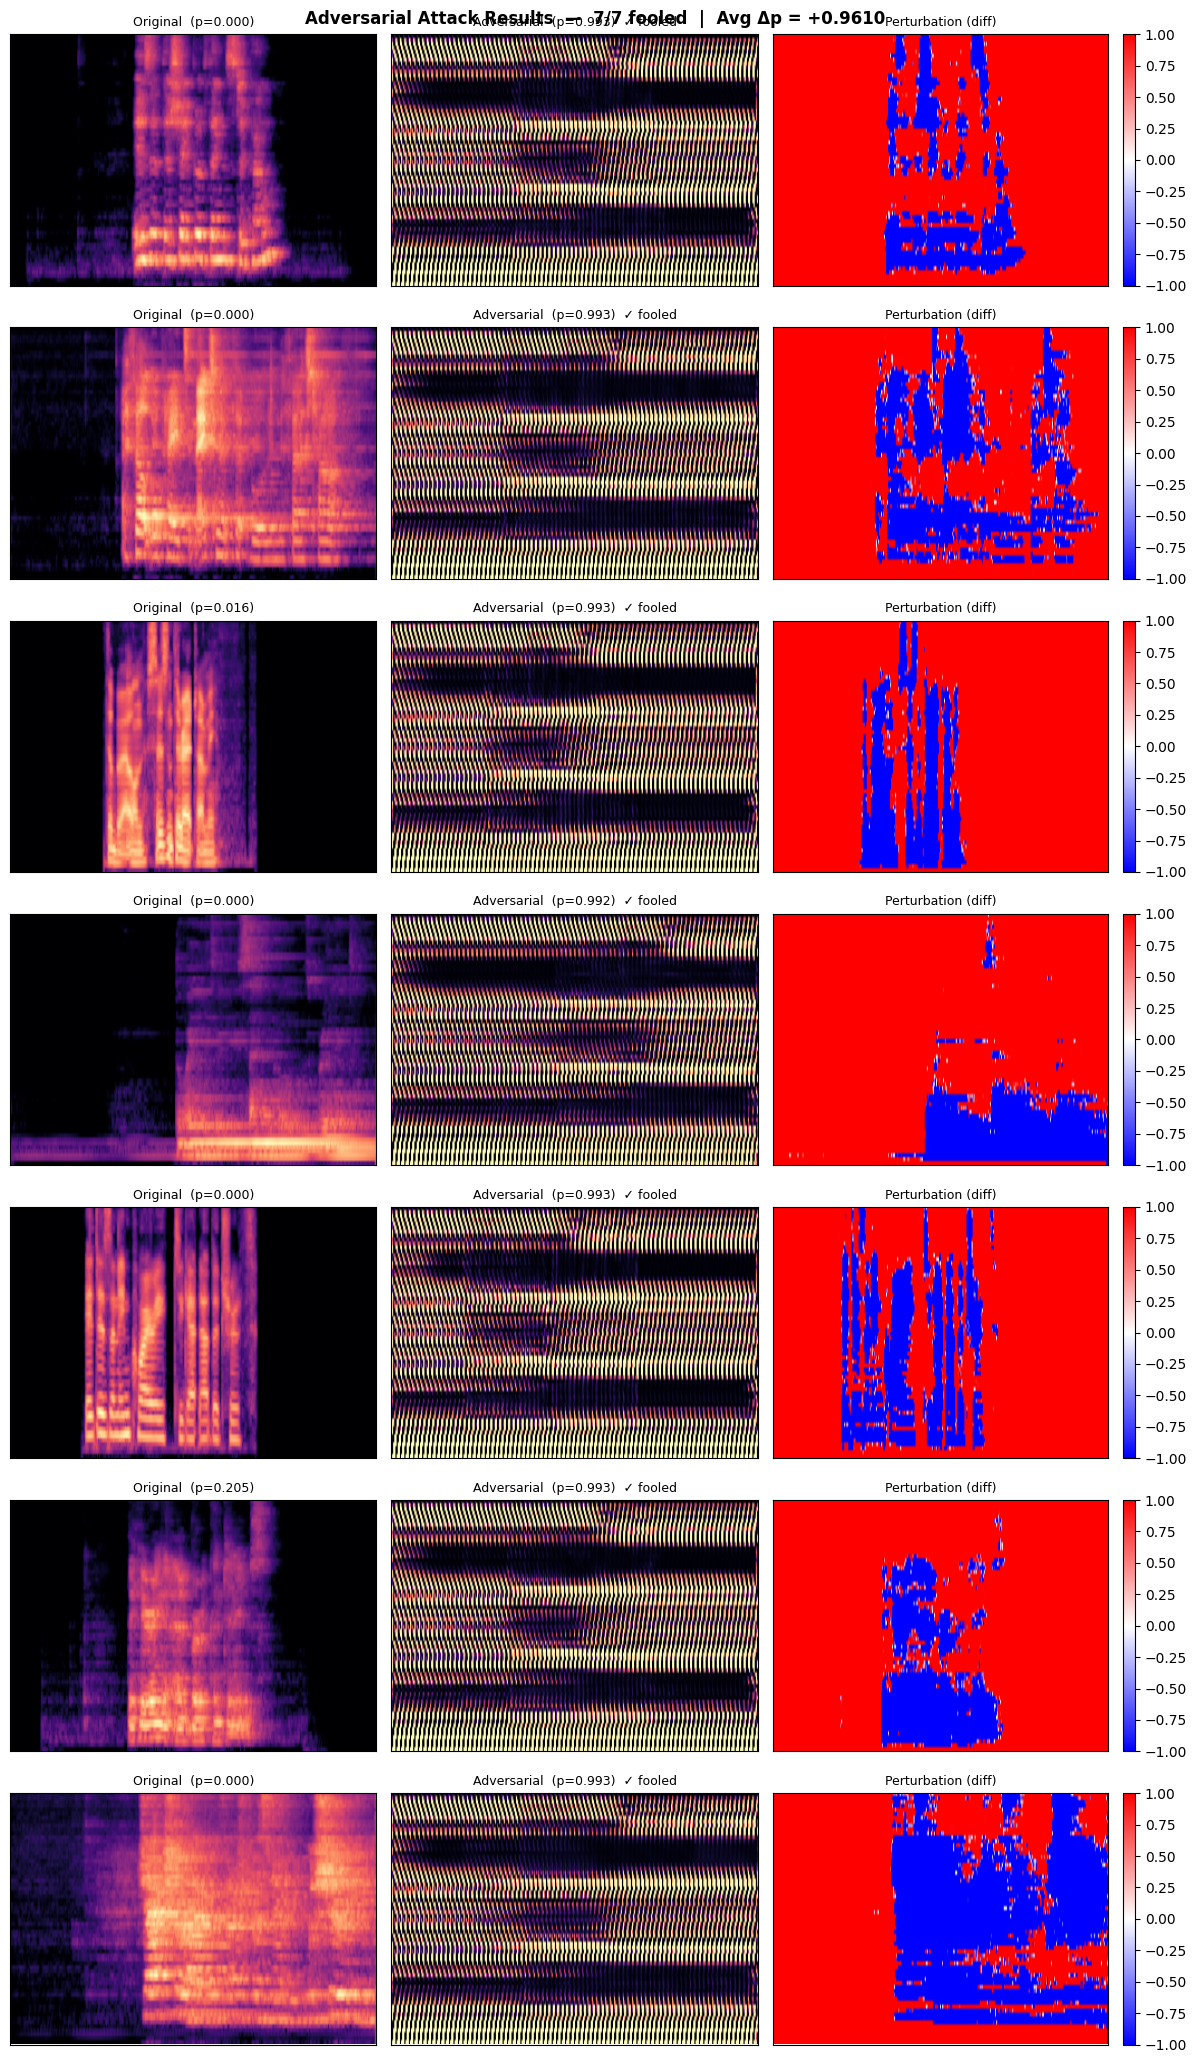

In [ ]:
def run_visual_inference(model, attackers, dataset, num_samples=7):
    model.eval()
    device = next(model.parameters()).device

    imagenet_mean = torch.tensor([0.485, 0.456], device=device).view(1, 2, 1, 1)
    imagenet_std  = torch.tensor([0.229, 0.224], device=device).view(1, 2, 1, 1)

    # Randomly sample indices
    indices = random.sample(range(len(dataset)), k=num_samples)
    for attacker in attackers:
      attacker.eval()

      results = []
      for idx in indices:
          sample_input, label = dataset[idx]
          img = sample_input.to(device).unsqueeze(0)

          with torch.no_grad():
              adv = attacker(img)

              orig_norm = (img  - imagenet_mean) / imagenet_std
              adv_norm  = (adv  - imagenet_mean) / imagenet_std

              prob_orig = torch.sigmoid(model(orig_norm)).item()
              prob_adv  = torch.sigmoid(model(adv_norm)).item()

          results.append({
              "idx":       idx,
              "label":     label,
              "img":       img.squeeze(0).cpu(),
              "adv":       adv.squeeze(0).cpu(),
              "prob_orig": prob_orig,
              "prob_adv":  prob_adv,
              "fooled":    prob_adv > 0.5  # attacker succeeded if prob > 0.5
          })

          print(f"Sample {idx:5d} | Label: {int(label)} | "
                f"Orig prob: {prob_orig:.4f} | "
                f"Adv prob: {prob_adv:.4f} | "
                f"Fooled: {'✓' if prob_adv > 0.5 else '✗'}")

      # Summary stats
      fooled_count = sum(r["fooled"] for r in results)
      avg_orig = np.mean([r["prob_orig"] for r in results])
      avg_adv  = np.mean([r["prob_adv"]  for r in results])
      print(f"\n── Summary ──────────────────────────────────")
      print(f"Fooled:        {fooled_count}/{num_samples}")
      print(f"Avg orig prob: {avg_orig:.4f}")
      print(f"Avg adv prob:  {avg_adv:.4f}")
      print(f"Avg delta:     {avg_adv - avg_orig:+.4f}")

      # Plot grid: each row = one sample [original | adversarial | diff]
      fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))
      if num_samples == 1:
          axes = axes[np.newaxis, :]

      for row, r in enumerate(results):
          orig_ch0 = r["img"][0].numpy()   # channel 0 of original
          adv_ch0  = r["adv"][0].numpy()   # channel 0 of adversarial
          diff     = adv_ch0 - orig_ch0    # perturbation

          axes[row, 0].imshow(orig_ch0, aspect="auto", origin="lower", cmap="magma")
          axes[row, 0].set_title(
              f"Original  (p={r['prob_orig']:.3f})", fontsize=9)

          axes[row, 1].imshow(adv_ch0, aspect="auto", origin="lower", cmap="magma")
          axes[row, 1].set_title(
              f"Adversarial  (p={r['prob_adv']:.3f})  "
              f"{'✓ fooled' if r['fooled'] else '✗'}", fontsize=9)

          im = axes[row, 2].imshow(diff, aspect="auto", origin="lower",
                                    cmap="bwr", vmin=-1, vmax=1)
          axes[row, 2].set_title("Perturbation (diff)", fontsize=9)
          plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

          for ax in axes[row]:
              ax.set_xticks([])
              ax.set_yticks([])

      plt.suptitle(
          f"Adversarial Attack Results  —  "
          f"{fooled_count}/{num_samples} fooled  |  "
          f"Avg Δp = {avg_adv - avg_orig:+.4f}",
          fontsize=12, fontweight="bold"
      )
      plt.tight_layout()
      plt.show()

    return results


# Usage
"""myAttacker = SoundAttacker().to(device)
myAttacker.load_state_dict(torch.load("best_att_model51.pth"))
myAttacker2 = SoundAttacker().to(device)
myAttacker2.load_state_dict(torch.load("best_att_model105.pth"))
myAttacker3 = SoundAttacker().to(device)
myAttacker3.load_state_dict(torch.load("best_att_model376.pth"))"""
myAttacker4 = SoundAttacker().to(device)
myAttacker4.load_state_dict(torch.load("best_att_model1.pth"))

attackers = [myAttacker4]

results = run_visual_inference(
    model=myModel,
    attackers=attackers,
    dataset=eval_ds,
    num_samples=7
)

In [ ]:
import torch
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

def evaluate_on_spoof_only(discriminator, generator, eval_dataset, device):
    """
    Evaluates the discriminator's detection rate and the attacker's success rate
    specifically on spoofed data.
    """
    discriminator.eval()
    generator.eval()

    total_spoof_samples = 0
    correctly_detected_spoof = 0
    fooled_by_attacker = 0

    # Filter only spoofed samples (label 0 for spoof, 1 for bonafide)
    # Adjust based on your specific label mapping
    spoof_loader = DataLoader(
        eval_dataset,
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

    imagenet_mean = torch.tensor([0.485, 0.456], device=device).view(1, 2, 1, 1)
    imagenet_std  = torch.tensor([0.229, 0.224], device=device).view(1, 2, 1, 1)

    with torch.no_grad():

        # Epoch-level progress bar
        epoch_bar = tqdm(spoof_loader, desc=f"Run", unit="batch")

        for x, _ in epoch_bar:

          x = x.to(device)
          batch_size = x.size(0)
          total_spoof_samples += batch_size

          # 1. Baseline Discriminator Performance
          # We check how many of these spoofed samples are correctly identified
          x_norm = (x - imagenet_mean) / imagenet_std
          logits_orig = discriminator(x_norm)
          preds_orig = torch.sigmoid(logits_orig) > 0.5
          # Since these are all spoofed, a "Correct Detection" means pred == 0
          correctly_detected_spoof += (preds_orig == 0).sum().item()

          # 2. Attacker Performance
          # Generate adversarial samples from the spoofed data
          x_adv = generator(x)
          x_adv = (x_adv - imagenet_mean) / imagenet_std

          # Pass adversarial samples back to the discriminator
          logits_adv = discriminator(x_adv)
          preds_adv = torch.sigmoid(logits_adv) > 0.5

          # Attack Success: The discriminator classifies a spoof as bonafide (pred == 1)
          fooled_by_attacker += (preds_adv == 1).sum().item()

          # Update tqdm with live metrics
          running_asr = (fooled_by_attacker / total_spoof_samples) * 100
          # Update the bar’s postfix with live metrics
          epoch_bar.set_postfix({
              "asr": f"{running_asr}"
          })

    # Metrics calculation
    det_rate = (correctly_detected_spoof / total_spoof_samples) * 100
    asr = (fooled_by_attacker / total_spoof_samples) * 100

    print(f"--- Evaluation on Spoofed Data ({total_spoof_samples} samples) ---")
    print(f"Discriminator Detection Rate (Baseline): {det_rate:.2f}%")
    print(f"Attacker Success Rate (ASR): {asr:.2f}%")

    return det_rate, asr

myAttacker4 = SoundAttacker().to(device)
myAttacker4.load_state_dict(torch.load("best_att_model1.pth"))

evaluate_on_spoof_only(myModel, myAttacker4, eval_ds, device)

Run:   0%|          | 0/796 [00:00<?, ?batch/s]

--- Evaluation on Spoofed Data (25445 samples) ---
Discriminator Detection Rate (Baseline): 87.61%
Attacker Success Rate (ASR): 100.00%


(87.61249754372176, 100.0)

In [18]:
from statsmodels.stats.proportion import proportion_confint

# Exemplu pentru Recall Real
count = 1
nobs = 2
lower, upper = proportion_confint(count, nobs, method='wilson')

print(f"Recall: {count/nobs:.2f} (95% CI: {lower:.2f} - {upper:.2f})")

Recall: 0.50 (95% CI: 0.09 - 0.91)


In [7]:
import numpy as np
from sklearn.metrics import f1_score
from sklearn.utils import resample

y_true = [0 if i < 50 else 1 for i in range(100)] # Corrected to have 50 zeros and 50 ones
y_pred = [0 for _ in range(50)] + [1 for _ in range(43)] + [0 for _ in range(7)] # predictions

scores = []
for _ in range(1000): # make 1000 simulations
    idx = resample(range(len(y_true))) # resample with replacement
    score = f1_score(np.array(y_true)[idx], np.array(y_pred)[idx])
    scores.append(score)

lower = np.percentile(scores, 2.5)
upper = np.percentile(scores, 97.5)
print(f"F1-Score Bootstrap 95% CI: {lower:.2f} - {upper:.2f}")

F1-Score Bootstrap 95% CI: 0.86 - 0.97


In [16]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# Matricea de contingență [ [Ambele_OK, Doar_Disc_OK], [Doar_Hibrid_OK, Ambele_Fail] ]
# Valorile tale estimate:
a = 56  # Ambele au ghicit
b = 0   # Doar Discriminatorul a ghicit
c = 41  # Hibridul a ghicit (Discriminatorul a zis Fake, dar era Real)
d = 16  # Ambele au eșuat

table = [[a, b],
         [c, d]]

# Rulăm testul (folosim exact=True pentru că avem valori mici în celule)
result = mcnemar(table, exact=True)

print("--- REZULTATE TEST MCNEMAR ---")
print(f"Statistica: {result.statistic}")
print(f"P-value: {result.pvalue:.10f}")

if result.pvalue < 0.05:
    print("\nCONCLUZIE: Diferența este SEMNIFICATIVĂ STATISTIC (p < 0.05).")
    print("Sistemul hibrid aduce o îmbunătățire reală")
else:
    print("\nCONCLUZIE: Nu există o diferență semnificativă statistic.")

--- REZULTATE TEST MCNEMAR ---
Statistica: 1.0
P-value: 0.0000000000

CONCLUZIE: Diferența este SEMNIFICATIVĂ STATISTIC (p < 0.05).
Sistemul hibrid aduce o îmbunătățire reală, nu datorată hazardului.
